# LightRAG Hybrid Search Enhancement Plan
## Vector + BM25 Keyword Search Integration

**Problem**: LightRAG의 모든 검색 경로가 벡터 유사도 검색에만 의존  
**Solution**: BM25 키워드 검색 경로를 추가하여 Hybrid Retrieval 구현

---

## 1. 현재 LightRAG 쿼리 아키텍처 분석

### 핵심 흐름 요약

```
사용자 쿼리
    │
    ▼
LLM 키워드 추출
    ├── hl_keywords (High-Level: 테마, 개념)
    └── ll_keywords (Low-Level: 구체적 엔티티)
    │
    ▼
검색 (모드별 분기)
    ├── local:  ll_keywords → entities_vdb.query() [벡터 유사도] → 그래프 탐색
    ├── global: hl_keywords → relationships_vdb.query() [벡터 유사도] → 그래프 탐색
    ├── hybrid: local + global 결합
    ├── mix:    hybrid + chunks_vdb.query() [벡터 유사도]
    └── naive:  chunks_vdb.query() [벡터 유사도] 단독
    │
    ▼
토큰 절단 → 청크 병합 → LLM 컨텍스트 생성 → 응답
```

### 문제점: 모든 검색이 벡터 유사도에만 의존

| 검색 대상 | 현재 방식 | 사용 함수 |
|-----------|----------|----------|
| 청크 (Chunks) | 벡터 유사도만 | `chunks_vdb.query()` |
| 엔티티 (Entities) | 벡터 유사도만 | `entities_vdb.query()` |
| 릴레이션 (Relations) | 벡터 유사도만 | `relationships_vdb.query()` |

## 2. 벡터 유사도 검색만으로는 부족한 이유

### 벡터 검색의 한계

| 문제 | 설명 | 예시 |
|------|------|------|
| **정확한 키워드 매칭 실패** | 의미적으로 유사하지만 정확한 단어가 포함된 결과를 놓침 | "GPT-4o" 검색 시 "GPT-4o-mini" 문서를 못 찾을 수 있음 |
| **고유명사/전문용어 취약** | 임베딩 모델이 도메인 특화 용어를 잘 처리하지 못함 | "HKUDS"라는 연구그룹명을 검색할 때 |
| **짧은 쿼리 성능 저하** | 1-2단어 쿼리의 임베딩 품질이 낮음 | "LightRAG" 한 단어 검색 |
| **Lexical Gap 없음** | 동일 단어가 포함된 문서를 오히려 낮게 랭킹할 수 있음 | 정확히 "retrieval augmented generation" 포함된 문서 |

### BM25가 보완하는 영역

- **정확한 용어 매칭**: TF-IDF 기반으로 쿼리 토큰이 문서에 정확히 출현하는지 측정
- **희귀 용어 부스팅**: IDF(Inverse Document Frequency)로 드문 용어에 높은 가중치
- **문서 길이 정규화**: 긴 문서 / 짧은 문서 간 공정한 비교
- **Zero-shot 강점**: 임베딩 모델 학습 데이터에 없는 용어도 매칭 가능

## 3. 제안: Hybrid Search (Vector + BM25) 추가

### 추천 기술: BM25 (via `rank_bm25` Python Library)

| 옵션 | 장점 | 단점 | 하루 프로젝트 적합성 |
|------|------|------|-------------------|
| **`rank_bm25` (Python)** | 인프라 불필요, 순수 Python, 즉시 사용 | 인메모리, 대규모 부적합 | **최적** |
| OpenSearch BM25 | 네이티브 하이브리드, 프로덕션 레디 | OpenSearch 인프라 필요 | 시간 부족 |
| Elasticsearch | 성숙한 FTS 엔진 | 무거운 인프라 | 시간 부족 |
| SQLite FTS5 | 경량, 영속적 | 한국어 토크나이저 별도 필요 | 보통 |

**결론: `rank_bm25`를 사용하여 프로토타입 구현 → 검증 후 OpenSearch BM25로 확장 가능**

### 두 가지 추가 경로

**경로 1: 청크 하이브리드 검색**
- 기존: `query → chunks_vdb.query()` (벡터만)
- 추가: `query → BM25(chunks)` (키워드 매칭)
- 결합: RRF (Reciprocal Rank Fusion)로 두 결과 병합

**경로 2: 엔티티/릴레이션 하이브리드 검색**
- 기존: `ll_keywords → entities_vdb.query()` (벡터만)
- 추가: `ll_keywords → BM25(entity_descriptions)` (키워드 매칭)
- 기존: `hl_keywords → relationships_vdb.query()` (벡터만)  
- 추가: `hl_keywords → BM25(relation_descriptions)` (키워드 매칭)

## 4. 아키텍처 다이어그램: Before vs After

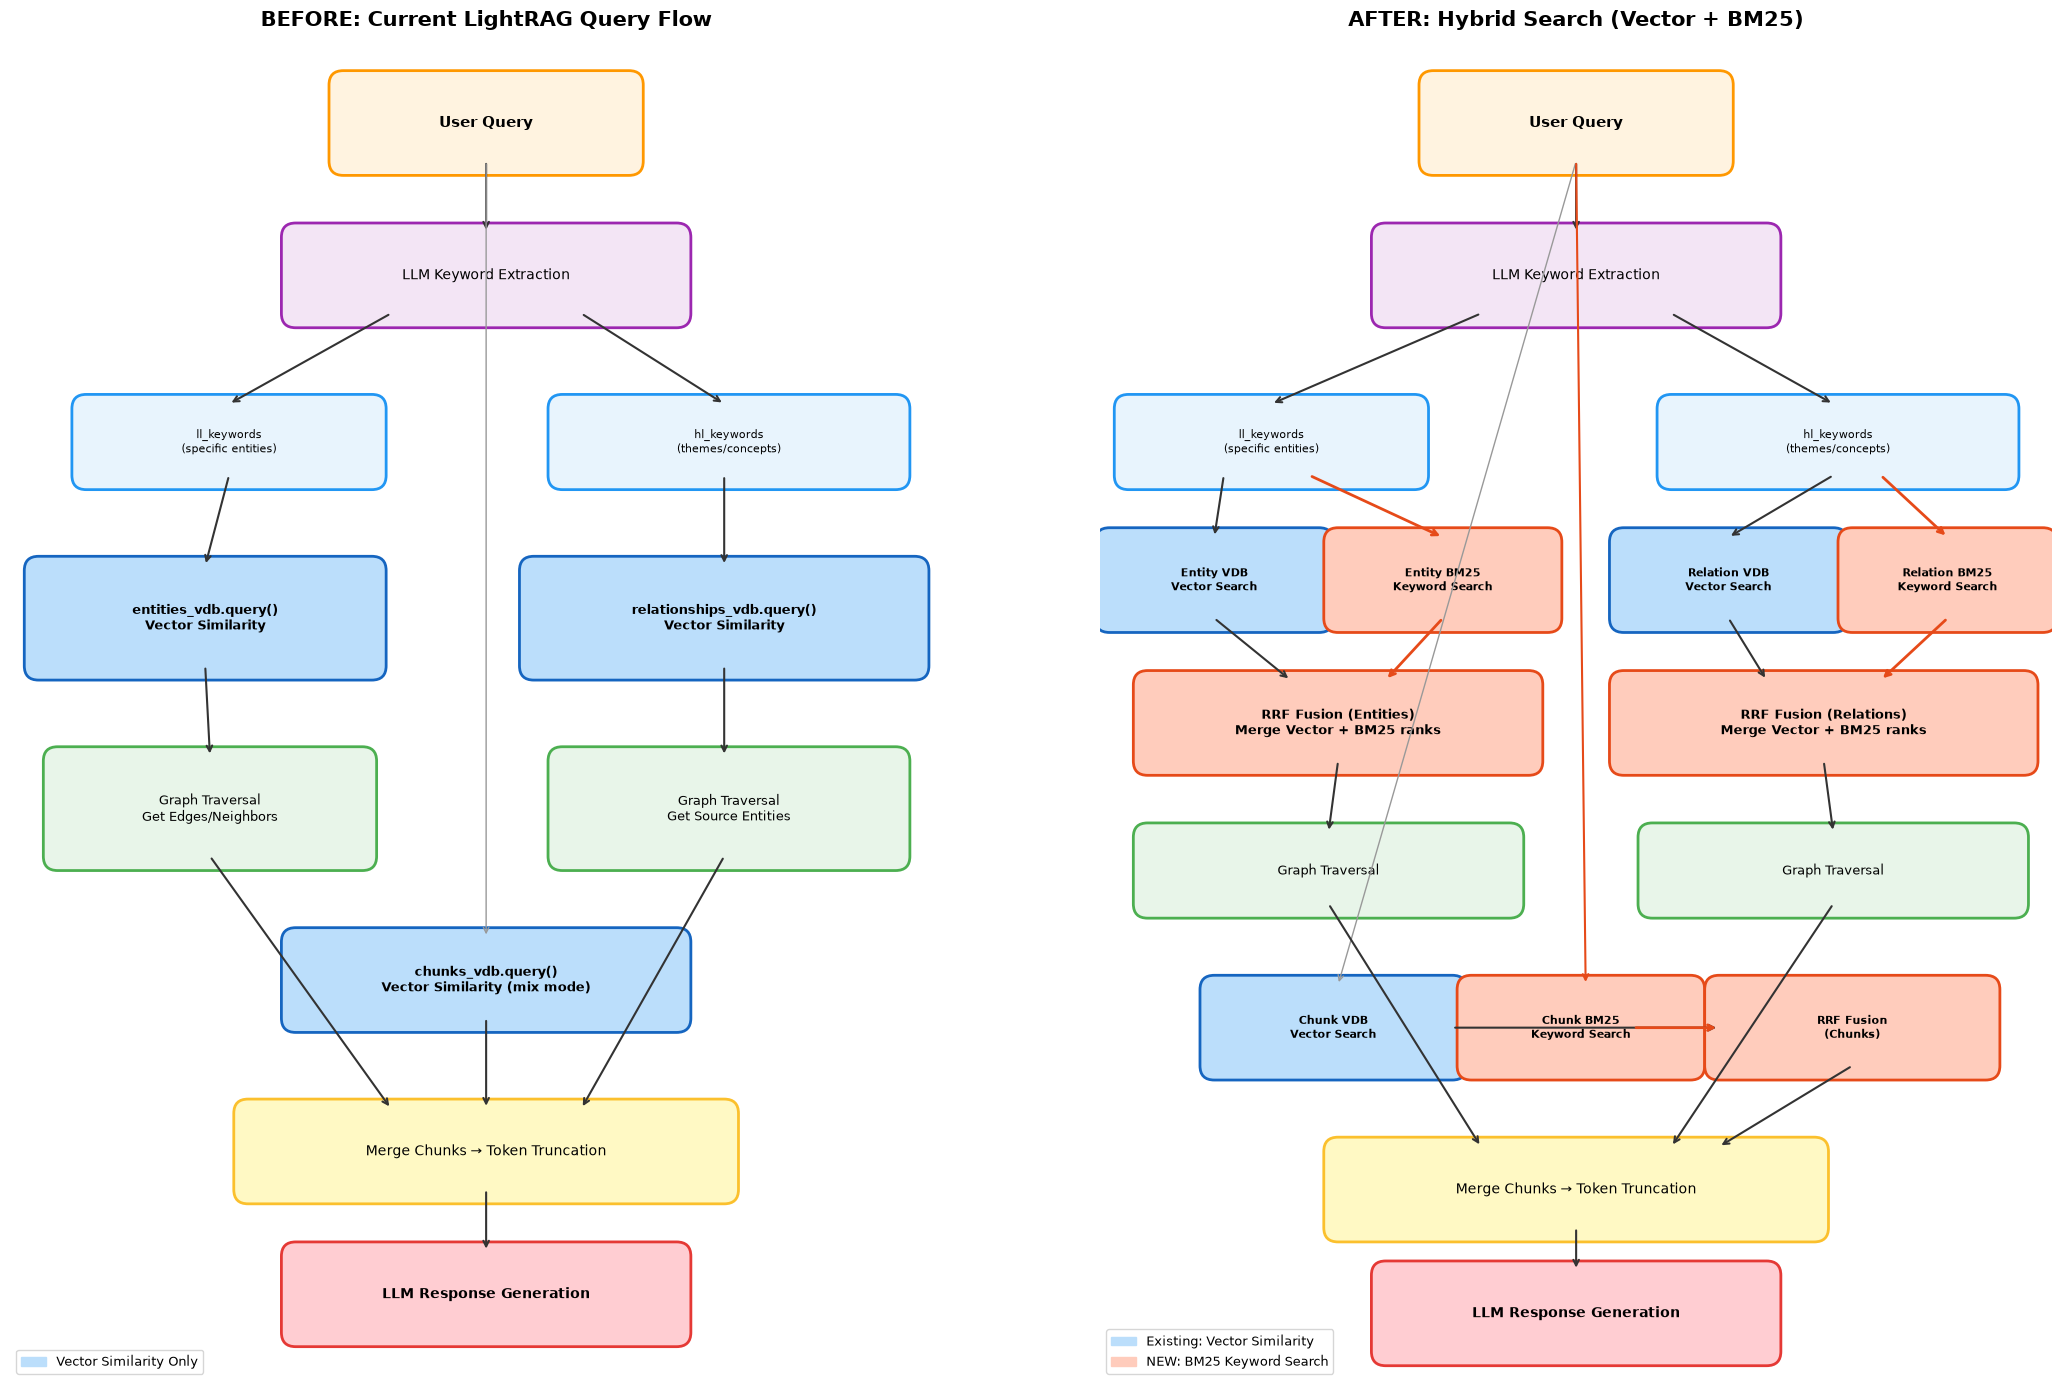

Diagram saved to architecture_diagram.png


In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(22, 14))

# ============================================================
# LEFT: BEFORE (Current LightRAG)
# ============================================================
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('BEFORE: Current LightRAG Query Flow', fontsize=15, fontweight='bold', pad=15)

def draw_box(ax, x, y, w, h, text, color='#E8F4FD', edge='#2196F3', fontsize=9, bold=False):
    rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.15",
                                     facecolor=color, edgecolor=edge, linewidth=2)
    ax.add_patch(rect)
    weight = 'bold' if bold else 'normal'
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize,
            fontweight=weight, wrap=True)

def draw_arrow(ax, x1, y1, x2, y2, color='#333', style='->', lw=1.5):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle=style, color=color, lw=lw))

# Query box
draw_box(ax, 3.5, 12.8, 3, 0.8, 'User Query', '#FFF3E0', '#FF9800', 11, True)

# LLM Keyword Extraction
draw_box(ax, 3, 11.2, 4, 0.8, 'LLM Keyword Extraction', '#F3E5F5', '#9C27B0', 10)
draw_arrow(ax, 5, 12.8, 5, 12.05)

# Keywords
draw_box(ax, 0.8, 9.5, 3, 0.7, 'll_keywords\n(specific entities)', '#E8F4FD', '#2196F3', 8)
draw_box(ax, 5.8, 9.5, 3.5, 0.7, 'hl_keywords\n(themes/concepts)', '#E8F4FD', '#2196F3', 8)
draw_arrow(ax, 4, 11.2, 2.3, 10.25)
draw_arrow(ax, 6, 11.2, 7.5, 10.25)

# Vector searches (BLUE = existing)
draw_box(ax, 0.3, 7.5, 3.5, 1.0, 'entities_vdb.query()\nVector Similarity', '#BBDEFB', '#1565C0', 9, True)
draw_box(ax, 5.5, 7.5, 4, 1.0, 'relationships_vdb.query()\nVector Similarity', '#BBDEFB', '#1565C0', 9, True)
draw_arrow(ax, 2.3, 9.5, 2.05, 8.55)
draw_arrow(ax, 7.5, 9.5, 7.5, 8.55)

# Graph traversal
draw_box(ax, 0.5, 5.5, 3.2, 1.0, 'Graph Traversal\nGet Edges/Neighbors', '#E8F5E9', '#4CAF50', 9)
draw_box(ax, 5.8, 5.5, 3.5, 1.0, 'Graph Traversal\nGet Source Entities', '#E8F5E9', '#4CAF50', 9)
draw_arrow(ax, 2.05, 7.5, 2.1, 6.55)
draw_arrow(ax, 7.5, 7.5, 7.5, 6.55)

# Chunk vector search (mix mode)
draw_box(ax, 3, 3.8, 4, 0.8, 'chunks_vdb.query()\nVector Similarity (mix mode)', '#BBDEFB', '#1565C0', 9, True)
draw_arrow(ax, 5, 12.8, 5, 4.65, '#999', '->', 1.0)

# Merge & Context
draw_box(ax, 2.5, 2.0, 5, 0.8, 'Merge Chunks → Token Truncation', '#FFF9C4', '#FBC02D', 10)
draw_arrow(ax, 2.1, 5.5, 4, 2.85)
draw_arrow(ax, 7.5, 5.5, 6, 2.85)
draw_arrow(ax, 5, 3.8, 5, 2.85)

# LLM Response
draw_box(ax, 3, 0.5, 4, 0.8, 'LLM Response Generation', '#FFCDD2', '#E53935', 10, True)
draw_arrow(ax, 5, 2.0, 5, 1.35)

# Legend
blue_patch = mpatches.Patch(color='#BBDEFB', label='Vector Similarity Only')
ax.legend(handles=[blue_patch], loc='lower left', fontsize=9)

# ============================================================
# RIGHT: AFTER (With BM25 Hybrid Search)
# ============================================================
ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('AFTER: Hybrid Search (Vector + BM25)', fontsize=15, fontweight='bold', pad=15)

# Query box
draw_box(ax, 3.5, 12.8, 3, 0.8, 'User Query', '#FFF3E0', '#FF9800', 11, True)

# LLM Keyword Extraction
draw_box(ax, 3, 11.2, 4, 0.8, 'LLM Keyword Extraction', '#F3E5F5', '#9C27B0', 10)
draw_arrow(ax, 5, 12.8, 5, 12.05)

# Keywords
draw_box(ax, 0.3, 9.5, 3, 0.7, 'll_keywords\n(specific entities)', '#E8F4FD', '#2196F3', 8)
draw_box(ax, 6, 9.5, 3.5, 0.7, 'hl_keywords\n(themes/concepts)', '#E8F4FD', '#2196F3', 8)
draw_arrow(ax, 4, 11.2, 1.8, 10.25)
draw_arrow(ax, 6, 11.2, 7.7, 10.25)

# EXISTING Vector searches (BLUE)
draw_box(ax, 0.1, 8.0, 2.2, 0.8, 'Entity VDB\nVector Search', '#BBDEFB', '#1565C0', 8, True)
draw_box(ax, 5.5, 8.0, 2.2, 0.8, 'Relation VDB\nVector Search', '#BBDEFB', '#1565C0', 8, True)

# NEW BM25 searches (RED/ORANGE = new)
draw_box(ax, 2.5, 8.0, 2.2, 0.8, 'Entity BM25\nKeyword Search', '#FFCCBC', '#E64A19', 8, True)
draw_box(ax, 7.9, 8.0, 2.0, 0.8, 'Relation BM25\nKeyword Search', '#FFCCBC', '#E64A19', 8, True)

draw_arrow(ax, 1.3, 9.5, 1.2, 8.85)
draw_arrow(ax, 2.2, 9.5, 3.6, 8.85, '#E64A19', '->', 2.0)
draw_arrow(ax, 7.7, 9.5, 6.6, 8.85)
draw_arrow(ax, 8.2, 9.5, 8.9, 8.85, '#E64A19', '->', 2.0)

# RRF Fusion boxes (NEW - ORANGE)
draw_box(ax, 0.5, 6.5, 4, 0.8, 'RRF Fusion (Entities)\nMerge Vector + BM25 ranks', '#FFCCBC', '#E64A19', 9, True)
draw_box(ax, 5.5, 6.5, 4.2, 0.8, 'RRF Fusion (Relations)\nMerge Vector + BM25 ranks', '#FFCCBC', '#E64A19', 9, True)
draw_arrow(ax, 1.2, 8.0, 2, 7.35)
draw_arrow(ax, 3.6, 8.0, 3, 7.35, '#E64A19', '->', 2.0)
draw_arrow(ax, 6.6, 8.0, 7, 7.35)
draw_arrow(ax, 8.9, 8.0, 8.2, 7.35, '#E64A19', '->', 2.0)

# Graph traversal
draw_box(ax, 0.5, 5.0, 3.8, 0.7, 'Graph Traversal', '#E8F5E9', '#4CAF50', 9)
draw_box(ax, 5.8, 5.0, 3.8, 0.7, 'Graph Traversal', '#E8F5E9', '#4CAF50', 9)
draw_arrow(ax, 2.5, 6.5, 2.4, 5.75)
draw_arrow(ax, 7.6, 6.5, 7.7, 5.75)

# Chunk hybrid search (NEW mix)
draw_box(ax, 1.2, 3.3, 2.5, 0.8, 'Chunk VDB\nVector Search', '#BBDEFB', '#1565C0', 8, True)
draw_box(ax, 3.9, 3.3, 2.3, 0.8, 'Chunk BM25\nKeyword Search', '#FFCCBC', '#E64A19', 8, True)
draw_box(ax, 6.5, 3.3, 2.8, 0.8, 'RRF Fusion\n(Chunks)', '#FFCCBC', '#E64A19', 8, True)

draw_arrow(ax, 5, 12.8, 2.5, 4.15, '#999', '->', 1.0)
draw_arrow(ax, 5, 12.8, 5.1, 4.15, '#E64A19', '->', 1.5)
draw_arrow(ax, 3.7, 3.7, 6.5, 3.7)
draw_arrow(ax, 5.6, 3.7, 6.5, 3.7, '#E64A19', '->', 2.0)

# Merge & Context
draw_box(ax, 2.5, 1.6, 5, 0.8, 'Merge Chunks → Token Truncation', '#FFF9C4', '#FBC02D', 10)
draw_arrow(ax, 2.4, 5.0, 4, 2.45)
draw_arrow(ax, 7.7, 5.0, 6, 2.45)
draw_arrow(ax, 7.9, 3.3, 6.5, 2.45)

# LLM Response
draw_box(ax, 3, 0.3, 4, 0.8, 'LLM Response Generation', '#FFCDD2', '#E53935', 10, True)
draw_arrow(ax, 5, 1.6, 5, 1.15)

# Legend
blue_patch = mpatches.Patch(color='#BBDEFB', label='Existing: Vector Similarity')
red_patch = mpatches.Patch(color='#FFCCBC', label='NEW: BM25 Keyword Search')
ax.legend(handles=[blue_patch, red_patch], loc='lower left', fontsize=9)

plt.tight_layout()
plt.savefig('architecture_diagram.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Diagram saved to architecture_diagram.png")

## 5. RRF (Reciprocal Rank Fusion) 병합 전략

두 검색 결과를 병합할 때 **RRF**를 사용합니다. 이는 OpenSearch, Elasticsearch 등 주요 검색엔진에서 표준으로 사용하는 방식입니다.

### 공식

$$RRF(d) = \sum_{r \in R} \frac{1}{k + rank_r(d)}$$

- $R$: 검색 결과 집합들 (Vector, BM25)
- $rank_r(d)$: 결과 집합 $r$에서 문서 $d$의 순위
- $k$: 상수 (보통 60, 낮은 순위의 영향을 조절)

### 왜 RRF인가?

| 방법 | 장점 | 단점 |
|------|------|------|
| **RRF** | 스코어 정규화 불필요, 강건함 | 하이퍼파라미터(k) 하나 |
| Linear Combination | 직관적 | 스코어 스케일이 달라 정규화 필요 |
| Learned Fusion | 최적 가중치 학습 | 학습 데이터 필요, 오버헤드 |

**RRF는 스코어 분포가 전혀 다른 Vector/BM25를 스코어 정규화 없이 순위만으로 병합 가능** → 가장 실용적

In [2]:
# RRF (Reciprocal Rank Fusion) 데모

def reciprocal_rank_fusion(
    ranked_lists: list[list[str]],
    k: int = 60
) -> list[tuple[str, float]]:
    """
    Reciprocal Rank Fusion - 여러 검색 결과를 순위 기반으로 병합
    
    Args:
        ranked_lists: 각 검색 시스템의 결과 리스트 (순위순)
        k: smoothing constant (기본 60)
    Returns:
        (doc_id, rrf_score) 튜플 리스트 (높은 점수순)
    """
    rrf_scores: dict[str, float] = {}
    
    for ranked_list in ranked_lists:
        for rank, doc_id in enumerate(ranked_list, start=1):
            rrf_scores[doc_id] = rrf_scores.get(doc_id, 0.0) + 1.0 / (k + rank)
    
    return sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)

# === 예시: 벡터 검색 vs BM25 검색 결과 병합 ===
vector_results = ["chunk_A", "chunk_B", "chunk_C", "chunk_D", "chunk_E"]
bm25_results   = ["chunk_C", "chunk_F", "chunk_A", "chunk_G", "chunk_B"]

fused = reciprocal_rank_fusion([vector_results, bm25_results], k=60)

print("=" * 60)
print("Vector 검색 결과:", vector_results)
print("BM25   검색 결과:", bm25_results)
print("=" * 60)
print("\nRRF 병합 결과 (높은 점수순):")
print("-" * 40)
for doc_id, score in fused:
    sources = []
    if doc_id in vector_results:
        sources.append(f"Vector #{vector_results.index(doc_id)+1}")
    if doc_id in bm25_results:
        sources.append(f"BM25 #{bm25_results.index(doc_id)+1}")
    print(f"  {doc_id:10s}  score={score:.6f}  ({', '.join(sources)})")

print("\n✓ chunk_A, chunk_C: 양쪽 모두에 등장 → 높은 RRF 점수")
print("✓ chunk_F, chunk_G: BM25에만 등장 → 벡터 검색이 놓친 키워드 매칭 결과 복원")

Vector 검색 결과: ['chunk_A', 'chunk_B', 'chunk_C', 'chunk_D', 'chunk_E']
BM25   검색 결과: ['chunk_C', 'chunk_F', 'chunk_A', 'chunk_G', 'chunk_B']

RRF 병합 결과 (높은 점수순):
----------------------------------------
  chunk_A     score=0.032266  (Vector #1, BM25 #3)
  chunk_C     score=0.032266  (Vector #3, BM25 #1)
  chunk_B     score=0.031514  (Vector #2, BM25 #5)
  chunk_F     score=0.016129  (BM25 #2)
  chunk_D     score=0.015625  (Vector #4)
  chunk_G     score=0.015625  (BM25 #4)
  chunk_E     score=0.015385  (Vector #5)

✓ chunk_A, chunk_C: 양쪽 모두에 등장 → 높은 RRF 점수
✓ chunk_F, chunk_G: BM25에만 등장 → 벡터 검색이 놓친 키워드 매칭 결과 복원


## 6. 구현 계획 (최소 변경, 1일 완성)

### 구현 범위

**수정 파일**: `lightrag/operate.py` (메인 쿼리 로직) + 새 유틸리티 모듈 1개  
**외부 의존성**: `rank_bm25` (pip install rank-bm25)  
**기존 코드 변경 최소화**: 검색 함수 내부에서 BM25 결과를 추가로 가져와 RRF로 병합

### Step-by-Step 구현

#### Step 1: BM25 인덱스 관리 모듈 (`lightrag/bm25_index.py`)

```python
"""BM25 인메모리 인덱스 - 청크/엔티티/릴레이션 텍스트에 대한 키워드 검색"""

from rank_bm25 import BM25Okapi
import re

class BM25Index:
    def __init__(self):
        self.corpus_ids: list[str] = []
        self.bm25: BM25Okapi | None = None
    
    def build(self, documents: dict[str, str]):
        """문서 dict {id: text} 로부터 BM25 인덱스 빌드"""
        self.corpus_ids = list(documents.keys())
        tokenized = [self._tokenize(doc) for doc in documents.values()]
        self.bm25 = BM25Okapi(tokenized)
    
    def query(self, query_text: str, top_k: int = 20) -> list[dict]:
        """BM25 검색 → [{id, score}, ...]"""
        if not self.bm25:
            return []
        scores = self.bm25.get_scores(self._tokenize(query_text))
        top_indices = scores.argsort()[-top_k:][::-1]
        return [
            {"id": self.corpus_ids[i], "score": float(scores[i])}
            for i in top_indices if scores[i] > 0
        ]
    
    @staticmethod
    def _tokenize(text: str) -> list[str]:
        return re.findall(r'\w+', text.lower())
```

#### Step 2: RRF 유틸리티 함수 추가

```python
def reciprocal_rank_fusion(
    vector_results: list[dict],   # [{id, distance, ...}]
    bm25_results: list[dict],     # [{id, score}]
    k: int = 60,
    id_field: str = "id",
) -> list[dict]:
    """벡터 + BM25 결과를 RRF로 병합"""
    rrf_scores = {}
    result_map = {}
    
    for rank, item in enumerate(vector_results, 1):
        doc_id = item[id_field]
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + 1/(k + rank)
        result_map[doc_id] = item
    
    for rank, item in enumerate(bm25_results, 1):
        doc_id = item[id_field]
        rrf_scores[doc_id] = rrf_scores.get(doc_id, 0) + 1/(k + rank)
        if doc_id not in result_map:
            result_map[doc_id] = item
    
    sorted_ids = sorted(rrf_scores, key=rrf_scores.get, reverse=True)
    return [result_map[doc_id] for doc_id in sorted_ids]
```

#### Step 3: `_get_vector_context()` 수정 (경로 1: 청크 하이브리드)

```python
# lightrag/operate.py - _get_vector_context() 내부
# 기존 벡터 검색
vector_results = await chunks_vdb.query(query, top_k=search_top_k, ...)

# [NEW] BM25 검색 추가
if global_config.get("enable_hybrid_search", False):
    bm25_results = chunks_bm25_index.query(query, top_k=search_top_k)
    results = reciprocal_rank_fusion(vector_results, bm25_results)
else:
    results = vector_results
```

#### Step 4: `_get_node_data()` 수정 (경로 2a: 엔티티 하이브리드)

```python
# lightrag/operate.py - _get_node_data() 내부
# 기존 벡터 검색
vector_results = await entities_vdb.query(ll_keywords, top_k=..., ...)

# [NEW] BM25 검색 추가
if global_config.get("enable_hybrid_search", False):
    bm25_results = entities_bm25_index.query(ll_keywords, top_k=...)
    results = reciprocal_rank_fusion(vector_results, bm25_results, 
                                      id_field="entity_name")
else:
    results = vector_results
```

#### Step 5: `_get_edge_data()` 수정 (경로 2b: 릴레이션 하이브리드)

```python
# 동일한 패턴으로 relationships_vdb.query() 결과에 BM25 결과 병합
```

### 설정

```python
rag = LightRAG(
    ...,
    addon_params={
        "enable_hybrid_search": True,   # 하이브리드 검색 ON/OFF
        "bm25_weight": 0.3,             # (선택) BM25 가중치 조절
    }
)
```

## 7. 기대 효과 및 평가 계획

### 기대 효과

| 시나리오 | 기존 (Vector Only) | 개선 (Vector + BM25) |
|----------|-------------------|---------------------|
| 고유명사 검색 ("HKUDS", "GPT-4o") | 임베딩 공간에서 유사 단어로 대체될 수 있음 | BM25가 정확한 토큰 매칭으로 보완 |
| 전문 용어 ("Retrieval Augmented Generation") | 의미적으로 비슷한 다른 문서가 상위 | 정확한 용어 포함 문서 우선 |
| 짧은 쿼리 (1-2 단어) | 임베딩 품질 저하 | BM25의 IDF 가중치가 효과적 |
| 긴 서술형 쿼리 | 벡터 검색이 효과적 | 벡터 검색 위주 + BM25 보조 |
| 혼합 쿼리 (개념 + 키워드) | 어느 한쪽만 잘 처리 | 양쪽 모두 처리 가능 |

### Recall 향상 메커니즘

```
Vector 검색:  [A, B, C, D, E]         ← 의미적 유사 문서
BM25 검색:    [C, F, A, G, B]         ← 키워드 일치 문서
RRF 병합:     [A, C, B, F, D, G, E]   ← 양쪽의 장점 결합

→ F, G는 벡터 검색으로는 발견 불가했지만 BM25로 복원됨
→ A, C는 양쪽 모두 상위 → RRF에서 더 높은 점수
```

### 정량 평가 방법 (시간 여유 시)

1. **테스트 데이터셋**: 10-20개 질문 + 정답 문서 쌍
2. **Recall@K 비교**: Vector Only vs Hybrid에서 정답 문서가 top-K에 포함되는 비율
3. **MRR (Mean Reciprocal Rank)**: 정답 문서의 평균 역순위

### 향후 확장 가능성

| 단계 | 내용 | 난이도 |
|------|------|--------|
| Phase 1 (이번) | `rank_bm25` 인메모리 프로토타입 | 하루 |
| Phase 2 | OpenSearch 네이티브 BM25 통합 | 2-3일 |
| Phase 3 | Learned Sparse Retrieval (SPLADE 등) | 1-2주 |
| Phase 4 | Cross-encoder Reranking 추가 | 1주 |

## 8. 코드 수정 지점 요약 (LightRAG 소스 기준)

### 수정이 필요한 정확한 위치

| 파일 | 함수 | 라인 | 변경 내용 |
|------|------|------|----------|
| `lightrag/operate.py` | `_get_vector_context()` | L4284 | `chunks_vdb.query()` 후 BM25 결과 병합 |
| `lightrag/operate.py` | `_get_node_data()` | L5155 | `entities_vdb.query()` 후 BM25 결과 병합 |
| `lightrag/operate.py` | `_get_edge_data()` | L5430 | `relationships_vdb.query()` 후 BM25 결과 병합 |
| `lightrag/operate.py` | `_perform_kg_search()` | L4315 | BM25 인덱스를 파라미터로 전달 |
| `lightrag/lightrag.py` | `LightRAG.__init__()` | - | BM25 인덱스 초기화 로직 추가 |
| **신규** | `lightrag/bm25_index.py` | - | BM25Index 클래스 + RRF 함수 |

### 핵심 원칙
- **기존 벡터 검색 코드를 건드리지 않음** — BM25 결과를 별도로 가져와 RRF로 병합만 추가
- **플래그 하나로 ON/OFF** — `enable_hybrid_search=False`가 기본값, 기존 동작 100% 보존
- **기존 테스트 깨뜨리지 않음** — 새 기능은 옵트인

## 9. BM25 인덱스 빌드 타이밍

BM25는 인메모리 인덱스이므로 **쿼리 전에 빌드**되어야 합니다.

### 빌드 대상 및 소스

| BM25 인덱스 | 빌드 소스 | 빌드 시점 |
|------------|----------|----------|
| `chunks_bm25` | `text_chunks_db` (KV Storage) 의 모든 청크 content | `initialize_storages()` 이후 |
| `entities_bm25` | `entities_vdb`에 저장된 entity description | `initialize_storages()` 이후 |
| `relations_bm25` | `relationships_vdb`에 저장된 relation description | `initialize_storages()` 이후 |

### 빌드 흐름

```python
# LightRAG.initialize_storages() 이후 호출
async def build_bm25_indices(self):
    """KV/VDB에서 텍스트를 읽어 BM25 인덱스 빌드"""
    
    # 1. 청크 BM25 인덱스
    all_chunks = await self.text_chunks.get_all()  # {id: {content, ...}}
    self.chunks_bm25 = BM25Index()
    self.chunks_bm25.build({k: v["content"] for k, v in all_chunks.items()})
    
    # 2. 엔티티 BM25 인덱스  
    all_entities = await self.entities_vdb.get_all_docs()
    self.entities_bm25 = BM25Index()
    self.entities_bm25.build({e["entity_name"]: e.get("content","") for e in all_entities})
    
    # 3. 릴레이션 BM25 인덱스
    all_relations = await self.relationships_vdb.get_all_docs()
    self.relations_bm25 = BM25Index()
    self.relations_bm25.build({make_key(r): r.get("content","") for r in all_relations})
```

### 증분 업데이트

새 문서가 삽입(`ainsert`)될 때 BM25 인덱스도 갱신 필요:
- **간단한 방법**: 삽입 후 전체 리빌드 (소규모 데이터셋에 충분)
- **최적화 방법**: 삽입된 청크만 추가 (Phase 2에서 구현)

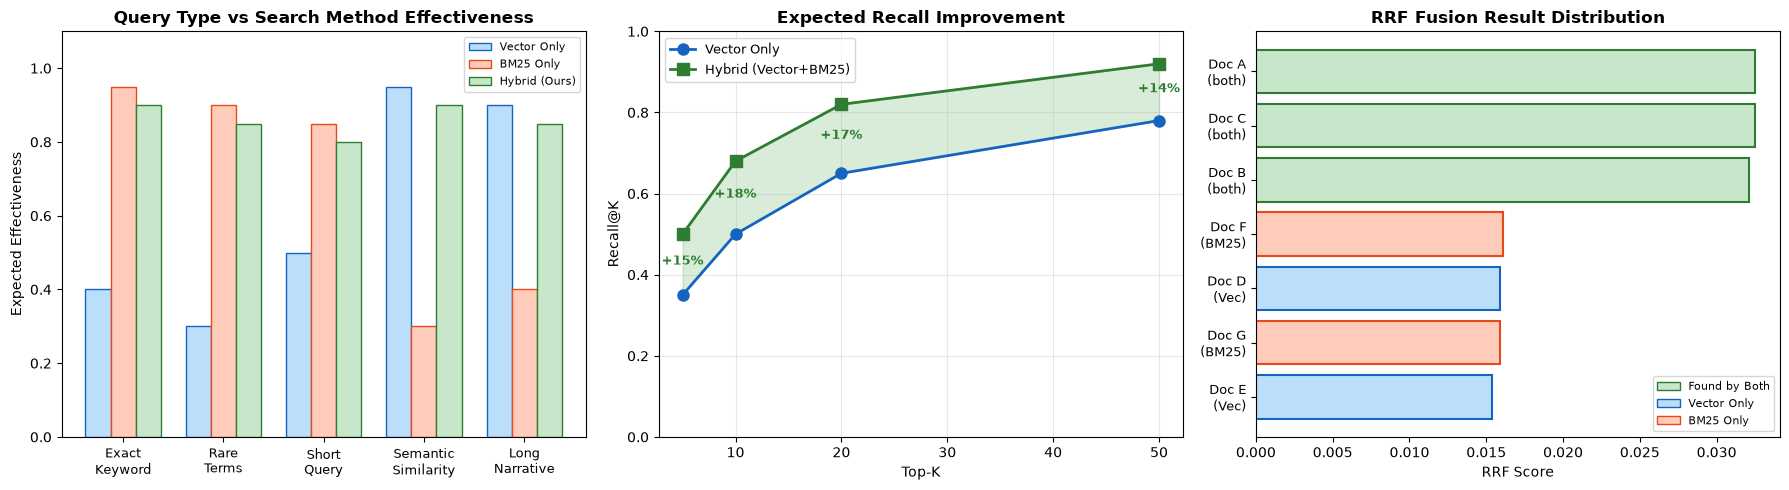

Charts saved to comparison_charts.png


In [3]:
# BM25 vs Vector 검색 특성 비교 시각화

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Chart 1: 쿼리 유형별 적합도 ---
ax = axes[0]
categories = ['Exact\nKeyword', 'Rare\nTerms', 'Short\nQuery', 'Semantic\nSimilarity', 'Long\nNarrative']
vector_scores = [0.4, 0.3, 0.5, 0.95, 0.9]
bm25_scores =   [0.95, 0.9, 0.85, 0.3, 0.4]
hybrid_scores = [0.9, 0.85, 0.8, 0.9, 0.85]

x = np.arange(len(categories))
w = 0.25
ax.bar(x - w, vector_scores, w, label='Vector Only', color='#BBDEFB', edgecolor='#1565C0')
ax.bar(x, bm25_scores, w, label='BM25 Only', color='#FFCCBC', edgecolor='#E64A19')
ax.bar(x + w, hybrid_scores, w, label='Hybrid (Ours)', color='#C8E6C9', edgecolor='#2E7D32')
ax.set_ylabel('Expected Effectiveness')
ax.set_title('Query Type vs Search Method Effectiveness', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=9)
ax.legend(fontsize=8)
ax.set_ylim(0, 1.1)

# --- Chart 2: Recall 개선 기대 (가상 시나리오) ---
ax = axes[1]
k_values = [5, 10, 20, 50]
vector_recall = [0.35, 0.50, 0.65, 0.78]
hybrid_recall = [0.50, 0.68, 0.82, 0.92]

ax.plot(k_values, vector_recall, 'o-', color='#1565C0', linewidth=2, markersize=8, label='Vector Only')
ax.plot(k_values, hybrid_recall, 's-', color='#2E7D32', linewidth=2, markersize=8, label='Hybrid (Vector+BM25)')
ax.fill_between(k_values, vector_recall, hybrid_recall, alpha=0.15, color='green')
ax.set_xlabel('Top-K')
ax.set_ylabel('Recall@K')
ax.set_title('Expected Recall Improvement', fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3)

# 개선폭 표시
for i, k in enumerate(k_values):
    diff = hybrid_recall[i] - vector_recall[i]
    ax.annotate(f'+{diff:.0%}', xy=(k, (vector_recall[i]+hybrid_recall[i])/2),
                fontsize=9, ha='center', color='#2E7D32', fontweight='bold')

# --- Chart 3: RRF 결과 분포 ---
ax = axes[2]
docs = ['Doc A\n(both)', 'Doc C\n(both)', 'Doc B\n(both)', 'Doc F\n(BM25)', 'Doc D\n(Vec)', 'Doc G\n(BM25)', 'Doc E\n(Vec)']
rrf_scores_vals = [0.0325, 0.0325, 0.0321, 0.0161, 0.0159, 0.0159, 0.0154]

colors = ['#C8E6C9' if '(both)' in d else '#BBDEFB' if '(Vec)' in d else '#FFCCBC' for d in docs]
edge_colors = ['#2E7D32' if '(both)' in d else '#1565C0' if '(Vec)' in d else '#E64A19' for d in docs]

bars = ax.barh(range(len(docs)), rrf_scores_vals, color=colors, edgecolor=edge_colors, linewidth=1.5)
ax.set_yticks(range(len(docs)))
ax.set_yticklabels(docs, fontsize=9)
ax.set_xlabel('RRF Score')
ax.set_title('RRF Fusion Result Distribution', fontweight='bold')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C8E6C9', edgecolor='#2E7D32', label='Found by Both'),
    Patch(facecolor='#BBDEFB', edgecolor='#1565C0', label='Vector Only'),
    Patch(facecolor='#FFCCBC', edgecolor='#E64A19', label='BM25 Only'),
]
ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('comparison_charts.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Charts saved to comparison_charts.png")

## 10. 타임라인

| 시간 | 작업 | 산출물 |
|------|------|--------|
| **0-2h** | `lightrag/bm25_index.py` 작성 (BM25Index + RRF) | 새 모듈 |
| **2-4h** | `operate.py` 3개 함수 수정 + 플래그 추가 | 코드 변경 |
| **4-5h** | `lightrag.py`에 BM25 인덱스 빌드 로직 추가 | 초기화 통합 |
| **5-7h** | 테스트 데이터로 검증 (Vector Only vs Hybrid 비교) | 결과 노트북 |
| **7-8h** | 발표 자료 정리, 다이어그램 최종화 | 이 노트북 |

---

## Summary

1. **현재 LightRAG**: 모든 검색이 벡터 유사도에만 의존 → 고유명사, 전문용어, 짧은 쿼리에 취약
2. **제안**: BM25 키워드 검색을 3개 지점(청크, 엔티티, 릴레이션)에 병렬 추가
3. **병합**: RRF (Reciprocal Rank Fusion)로 스코어 정규화 없이 순위 기반 병합
4. **구현**: `rank_bm25` 라이브러리로 인프라 없이 당일 프로토타입 가능
5. **기대**: Recall@K 15-20%p 향상, 특히 키워드 매칭이 중요한 쿼리에서 큰 개선